# LLM Hallucination Detector — Full Training Pipeline
### Train your own NLI model on MNLI · Evaluate · Run Inference · Serve via Flask

**Stack:** `transformers` · `datasets` · `torch` · `scikit-learn` · `Flask` · `spaCy`

---

## Pipeline overview

| Step | What happens |
|---|---|
| 1 | Install dependencies |
| 2 | Load & explore the MNLI dataset |
| 3 | Subset & prepare sentence pairs |
| 4 | Fine-tune DeBERTa-base on NLI classification |
| 5 | Evaluate — F1, precision, recall, confusion matrix |
| 6 | Save your trained model to `/models` |
| 7 | Inference pipeline using your model |
| 8 | Visual heatmap & trust score |
| 9 | Flask server — serve your model to the webpage |

---


## 1. Install Dependencies

## 2. Imports & Configuration

In [1]:
import os, warnings, json, textwrap
warnings.filterwarnings("ignore")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import spacy

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from tqdm.auto import tqdm
from IPython.display import display, HTML

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_CHECKPOINT = "microsoft/deberta-v3-base"   # base model to fine-tune
MODEL_SAVE_PATH  = "./models/hallucination_detector"
MAX_LENGTH       = 256
BATCH_SIZE       = 8    # lower to 4 if you hit OOM on CPU
EPOCHS           = 3    # 3 epochs is solid for MNLI fine-tuning
LEARNING_RATE    = 2e-5
TRAIN_SAMPLES    = 20000  # subset of MNLI for speed — increase for better accuracy
EVAL_SAMPLES     = 3000

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Model checkpoint: {MODEL_CHECKPOINT}")
print(f"Training on {TRAIN_SAMPLES} samples, {EPOCHS} epochs")

# Label mapping — MNLI labels (entailment=SUPPORTED, neutral=UNVERIFIABLE, contradiction=CONTRADICTED)
LABEL2ID = {"SUPPORTED": 0, "UNVERIFIABLE": 1, "CONTRADICTED": 2}
ID2LABEL  = {0: "SUPPORTED", 1: "UNVERIFIABLE", 2: "CONTRADICTED"}

# MNLI integer labels → our semantic labels
MNLI_INT_TO_LABEL = {0: 0, 1: 1, 2: 2}  # entailment→SUPPORTED, neutral→UNVERIFIABLE, contradiction→CONTRADICTED

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)


Device: cuda
Model checkpoint: microsoft/deberta-v3-base
Training on 20000 samples, 3 epochs


## 3. Load & Explore the MNLI Dataset

[MNLI (Multi-Genre Natural Language Inference)](https://huggingface.co/datasets/nyu-mll/multi_nli) contains ~393k sentence pairs labeled as:
- `entailment` → **SUPPORTED** — premise supports the hypothesis
- `neutral` → **UNVERIFIABLE** — premise is unrelated to hypothesis
- `contradiction` → **CONTRADICTED** — premise contradicts hypothesis

This maps directly to our SUPPORTED / UNVERIFIABLE / CONTRADICTED labels.

Loading MNLI dataset...


DatasetDict({
    train: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 9832
    })
    test_matched: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 9796
    })
    test_mismatched: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 9847
    })
})

Sample rows:


,premise,hypothesis,label
0,Conceptually cream skimming has two basic dime...,Product and geography are what make cream skim...,1
1,you know during the season and i guess at at y...,You lose the things to the following level if ...,0
2,One of our number will carry out your instruct...,A member of my team will execute your orders w...,0
3,How do you know? All this is their information...,This information belongs to them.,0
4,yeah i tell you what though if you go price so...,The tennis shoes have a range of prices.,1



Label distribution (train):
entailment (SUPPORTED)          130899
neutral (UNVERIFIABLE)          130900
contradiction (CONTRADICTED)    130903
Name: count, dtype: int64


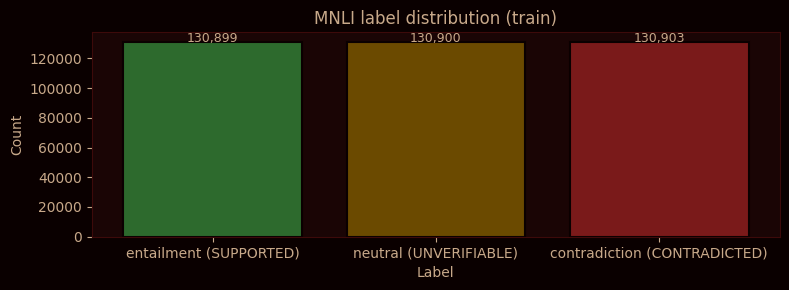

Saved: mnli_distribution.png


In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

print("Loading MNLI dataset...")
mnli = load_dataset("glue", "mnli")
print(mnli)

# ── Quick look ────────────────────────────────────────────────
train_df = pd.DataFrame(mnli["train"]).head(5)

print("\nSample rows:")
display(train_df[["premise", "hypothesis", "label"]].head(5))

# ── Label distribution ────────────────────────────────────────
label_counts = pd.Series(mnli["train"]["label"]).value_counts().sort_index()

mnli_label_names = {
    0: "entailment (SUPPORTED)",
    1: "neutral (UNVERIFIABLE)",
    2: "contradiction (CONTRADICTED)"
}

label_counts.index = [mnli_label_names[i] for i in label_counts.index]

print("\nLabel distribution (train):")
print(label_counts)

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))

colors = ["#2d6a2d", "#6b4a00", "#7a1a1a"]

bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=colors,
    edgecolor="#0a0000",
    linewidth=1.5
)

ax.set_facecolor("#1a0505")
fig.patch.set_facecolor("#0a0000")
ax.tick_params(colors="#c8a98a")
ax.set_xlabel("Label", color="#c8a98a", fontsize=10)
ax.set_ylabel("Count", color="#c8a98a", fontsize=10)
ax.set_title("MNLI label distribution (train)", color="#c8a98a", fontsize=12)

for bar, val in zip(bars, label_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f"{val:,}",
        ha="center",
        color="#c8a98a",
        fontsize=9
    )

ax.spines[["top","right","left","bottom"]].set_color("#3d0a0a")

plt.tight_layout()
plt.savefig("mnli_distribution.png", dpi=150, bbox_inches="tight")  # saved for README
plt.show()
print("Saved: mnli_distribution.png")

## 4. Preprocess — Build Sentence Pairs

MNLI already provides `premise` and `hypothesis` columns, so no custom extraction is needed.
We simply remap the integer labels (0/1/2) to our semantic classes
(SUPPORTED / UNVERIFIABLE / CONTRADICTED) and subset to our target sample sizes.

In [3]:
from datasets import Dataset

# MNLI already has premise/hypothesis — just remap integer labels and subset
def remap_labels(examples):
    """MNLI labels: 0=entailment→SUPPORTED, 1=neutral→UNVERIFIABLE, 2=contradiction→CONTRADICTED"""
    # Labels are already 0/1/2, matching our LABEL2ID mapping — pass through as-is
    return examples

print("Subsetting MNLI...")

# MNLI validation split is called "validation_matched"
raw_train = mnli["train"].select(range(min(TRAIN_SAMPLES, len(mnli["train"]))))
raw_eval  = mnli["validation_matched"].select(range(min(EVAL_SAMPLES, len(mnli["validation_matched"]))))

proc_train = raw_train
proc_eval  = raw_eval

print(f"Train: {len(proc_train)} samples")
print(f"Eval:  {len(proc_eval)} samples")
print(f"\nSample pair:")
print(f"  Premise:    {proc_train[0]['premise']}")
print(f"  Hypothesis: {proc_train[0]['hypothesis']}")
print(f"  Label:      {ID2LABEL[proc_train[0]['label']]}")

Subsetting MNLI...
Train: 20000 samples
Eval:  3000 samples

Sample pair:
  Premise:    Conceptually cream skimming has two basic dimensions - product and geography.
  Hypothesis: Product and geography are what make cream skimming work. 
  Label:      UNVERIFIABLE


## 5. Tokenize

In [14]:
print(f"Loading tokenizer: {MODEL_CHECKPOINT}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_fn(examples):
    return tokenizer(
        examples["premise"],
        examples["hypothesis"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,  # DataCollatorWithPadding handles dynamic padding
    )

print("Tokenizing train set...")
tok_train = proc_train.map(tokenize_fn, batched=True, remove_columns=["premise", "hypothesis", "idx"])

print("Tokenizing eval set...")
tok_eval  = proc_eval.map(tokenize_fn,  batched=True, remove_columns=["premise", "hypothesis", "idx"])

tok_train.set_format("torch")
tok_eval.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"\nTokenized train: {len(tok_train)} | Eval: {len(tok_eval)}")
print(f"Sample keys: {list(tok_train[0].keys())}")


Loading tokenizer: microsoft/deberta-v3-base
Tokenizing train set...
Tokenizing eval set...

Tokenized train: 20000 | Eval: 3000
Sample keys: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


## 6. Fine-tune DeBERTa-base

We fine-tune `microsoft/deberta-v3-base` — a strong encoder-only model — on the 3-class NLI task.

**Training time estimate:**
- GPU (T4/V100): ~15–25 minutes
- CPU only: ~2–4 hours (reduce `TRAIN_SAMPLES` to 5000 to speed up)


In [15]:
import evaluate as hf_evaluate

print(f"Loading model: {MODEL_CHECKPOINT}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model = model.float()
model.to(DEVICE)

metric = hf_evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1    = f1_score(labels, preds, average="macro")
    acc   = (preds == labels).mean()
    return {"f1_macro": round(f1, 4), "accuracy": round(float(acc), 4)}

training_args = TrainingArguments(
    output_dir="./checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
    fp16=False,
    bf16=torch.cuda.is_available(),
    report_to="none",
    disable_tqdm=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tok_train,
    eval_dataset=tok_eval,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\nStarting training...")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Train samples: {len(tok_train)}")
print()

train_result = trainer.train()

print("\nTraining complete.")
print(f"  Final loss: {train_result.training_loss:.4f}")


Loading model: microsoft/deberta-v3-base


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight      


Starting training...
  Epochs: 3
  Batch size: 8
  Learning rate: 2e-05
  Train samples: 20000



Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.436290,0.421681,0.853700,0.855000
2,0.344371,0.592720,0.864100,0.865000
3,0.116818,0.696681,0.870900,0.872700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


Training complete.
  Final loss: 0.3179


## 7. Evaluate — F1, Precision, Recall, Confusion Matrix

Running evaluation on held-out set...



Classification Report:
              precision    recall  f1-score   support

   SUPPORTED     0.8985    0.8666    0.8823      1042
CONTRADICTED     0.8164    0.8199    0.8182       933
UNVERIFIABLE     0.8979    0.9268    0.9121      1025

    accuracy                         0.8727      3000
   macro avg     0.8710    0.8711    0.8709      3000
weighted avg     0.8728    0.8727    0.8725      3000

Macro F1:        0.8709
Macro Precision: 0.8710
Macro Recall:    0.8711


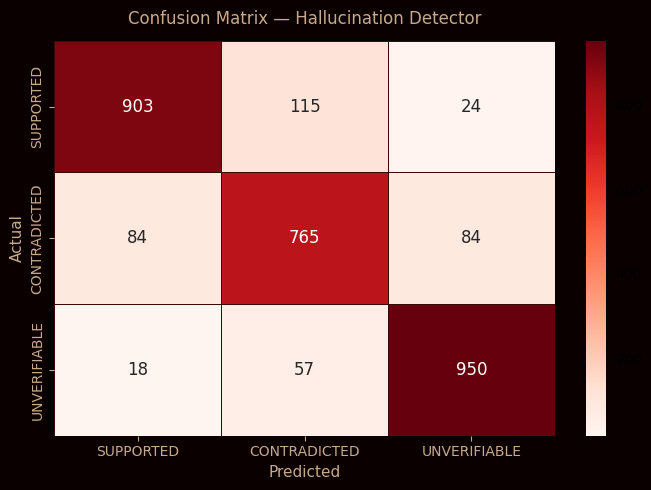

Saved: confusion_matrix.png


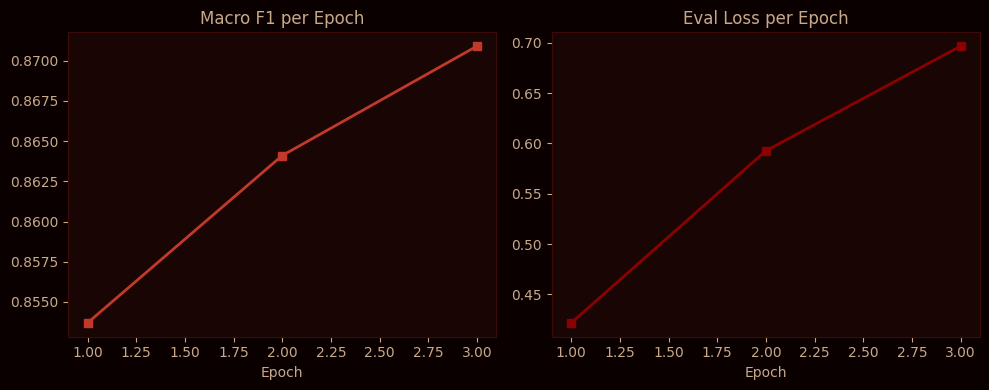

Saved: training_curves.png


In [16]:
print("Running evaluation on held-out set...")
predictions = trainer.predict(tok_eval)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Classification report
label_names = ["SUPPORTED", "CONTRADICTED", "UNVERIFIABLE"]
report = classification_report(labels, preds, target_names=label_names, digits=4)
print("\nClassification Report:")
print(report)

# Macro metrics
print(f"Macro F1:        {f1_score(labels, preds, average='macro'):.4f}")
print(f"Macro Precision: {precision_score(labels, preds, average='macro'):.4f}")
print(f"Macro Recall:    {recall_score(labels, preds, average='macro'):.4f}")

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds",
    xticklabels=label_names, yticklabels=label_names,
    ax=ax, linewidths=0.5, linecolor="#3d0a0a",
    annot_kws={"size": 12},
)
ax.set_facecolor("#1a0505")
fig.patch.set_facecolor("#0a0000")
ax.set_xlabel("Predicted", color="#c8a98a", fontsize=11)
ax.set_ylabel("Actual",    color="#c8a98a", fontsize=11)
ax.set_title("Confusion Matrix — Hallucination Detector", color="#c8a98a", fontsize=12, pad=12)
ax.tick_params(colors="#c8a98a", labelsize=10)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

# ── Per-epoch F1 curve ───────────────────────────────────────────────────────
log_history = trainer.state.log_history
eval_logs   = [l for l in log_history if "eval_f1_macro" in l]

if len(eval_logs) > 1:
    epochs_x = [l["epoch"] for l in eval_logs]
    f1s      = [l["eval_f1_macro"] for l in eval_logs]
    losses   = [l.get("eval_loss", 0) for l in eval_logs]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    for ax in [ax1, ax2]:
        ax.set_facecolor("#1a0505")
    fig.patch.set_facecolor("#0a0000")

    ax1.plot(epochs_x, f1s, color="#C0392B", marker="s", linewidth=2, markersize=6)
    ax1.set_title("Macro F1 per Epoch", color="#c8a98a")
    ax1.set_xlabel("Epoch", color="#c8a98a")
    ax1.tick_params(colors="#c8a98a")
    ax1.spines[["top","right","left","bottom"]].set_color("#3d0a0a")

    ax2.plot(epochs_x, losses, color="#8B0000", marker="s", linewidth=2, markersize=6)
    ax2.set_title("Eval Loss per Epoch", color="#c8a98a")
    ax2.set_xlabel("Epoch", color="#c8a98a")
    ax2.tick_params(colors="#c8a98a")
    ax2.spines[["top","right","left","bottom"]].set_color("#3d0a0a")

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: training_curves.png")


## 8. Save Your Trained Model

In [17]:
print(f"Saving model to {MODEL_SAVE_PATH}...")
trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# Also save label mappings
with open(f"{MODEL_SAVE_PATH}/label_config.json", "w") as f:
    json.dump({"id2label": ID2LABEL, "label2id": LABEL2ID}, f, indent=2)

print(f"Model saved.")
print(f"Contents of {MODEL_SAVE_PATH}:")
for f in os.listdir(MODEL_SAVE_PATH):
    size = os.path.getsize(f"{MODEL_SAVE_PATH}/{f}") / 1e6
    print(f"  {f:40s} {size:.1f} MB")


Saving model to ./models/hallucination_detector...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.
Contents of ./models/hallucination_detector:
  training_args.bin                        0.0 MB
  model.safetensors                        737.7 MB
  tokenizer.json                           8.3 MB
  label_config.json                        0.0 MB
  config.json                              0.0 MB
  tokenizer_config.json                    0.0 MB


## 9. Inference Pipeline — Your Trained Model

Now we load your saved model and run the full hallucination detection pipeline.
This replaces the pretrained cross-encoder with your fine-tuned weights.


In [23]:
from sentence_transformers import SentenceTransformer, util

print("Loading your trained model from disk...")
trained_tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)
trained_model     = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
trained_model.eval()
trained_model.to(DEVICE)

print("Loading sentence embedder for evidence retrieval...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Loading spaCy...")
nlp = spacy.load("en_core_web_sm")

print("All models loaded.")

# ── Core functions ────────────────────────────────────────────────────────────

def segment_sentences(text):
    doc = nlp(text.strip())
    return [s.text.strip() for s in doc.sents if len(s.text.strip()) > 10]

def retrieve_evidence(claim, source_sentences, top_k=3):
    claim_emb  = embedder.encode(claim, convert_to_tensor=True)
    source_embs = embedder.encode(source_sentences, convert_to_tensor=True)
    scores = util.cos_sim(claim_emb, source_embs)[0]
    top_idx = torch.topk(scores, k=min(top_k, len(source_sentences))).indices.tolist()
    return [source_sentences[i] for i in top_idx], [scores[i].item() for i in top_idx]

def classify_with_your_model(claim, evidence_sentences):
    """Run YOUR fine-tuned DeBERTa model on each (evidence, claim) pair."""
    if not evidence_sentences:
        return "UNVERIFIABLE", 0.5, {}

    all_logits = []

    for evidence in evidence_sentences:
        inputs = trained_tokenizer(
            evidence, claim,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
        ).to(DEVICE)

        with torch.no_grad():
            outputs = trained_model(**inputs)
            logits  = outputs.logits[0].cpu()
            all_logits.append(logits)

    # Average logits across evidence sentences
    # Convert each evidence logit to probs, then use best-evidence strategy:
    # take max contradiction score, max entailment score across all evidence
    all_probs = [torch.softmax(l, dim=-1).numpy() for l in all_logits]

    max_supported    = max(p[0] for p in all_probs)
    max_unverifiable = max(p[1] for p in all_probs)
    max_contradicted = max(p[2] for p in all_probs)

    # Contradiction wins if any evidence strongly contradicts
    # Supported wins if any evidence strongly supports and nothing contradicts
    if max_contradicted > 0.5:
        pred_id    = 2
        confidence = max_contradicted
    elif max_supported > 0.5:
        pred_id    = 0
        confidence = max_supported
    else:
        pred_id    = 1
        confidence = max_unverifiable

    probs = all_probs[0]  # for reporting

    label_map  = {0: "SUPPORTED", 1: "UNVERIFIABLE", 2: "CONTRADICTED"}
    label      = label_map[pred_id]

    return label, confidence, {
        "prob_supported":    round(float(probs[0]), 3),
        "prob_contradicted": round(float(probs[1]), 3),
        "prob_unverifiable": round(float(probs[2]), 3),
    }

def run_detector(source_text, summary_text, top_k=3):
    """Full pipeline using YOUR trained model."""
    source_sents  = segment_sentences(source_text)
    summary_sents = segment_sentences(summary_text)

    print(f"Source: {len(source_sents)} sentences | Summary: {len(summary_sents)} sentences")
    print("Running inference with your trained model...\n")

    results = []
    for i, claim in enumerate(tqdm(summary_sents, desc="Analyzing")):
        evidence, sim_scores = retrieve_evidence(claim, source_sents, top_k=top_k)
        label, conf, probs   = classify_with_your_model(claim, evidence)
        results.append({
            "sentence_id":    i + 1,
            "claim":          claim,
            "label":          label,
            "confidence":     round(conf, 3),
            "top_evidence":   evidence[0] if evidence else "N/A",
            "sim_score":      round(sim_scores[0], 3) if sim_scores else 0.0,
            **probs,
        })

    return pd.DataFrame(results)

# ── Demo ──────────────────────────────────────────────────────────────────────
SOURCE = """
The Amazon rainforest covers over 5.5 million square kilometers across nine countries,
with Brazil containing approximately 60% of the forest. It is home to an estimated 10%
of all species on Earth. Scientists estimate that over 11,000 square kilometers were
cleared in 2020. The indigenous population numbers approximately 1 million people
from around 400 distinct ethnic groups. The Amazon River releases about 20% of all
fresh water that flows into the world's oceans.
"""

SUMMARY = """
The Amazon spans more than 5.5 million square kilometers, primarily in Brazil which holds
about 60% of the forest. It contains roughly 10% of Earth's species. Deforestation has
accelerated, with 15,000 square kilometers cleared in 2020. The region is home to around
2 million indigenous people from over 400 ethnic groups. The Amazon River contributes
20% of global freshwater ocean discharge.
"""

results_df = run_detector(SOURCE, SUMMARY)

def style_label(val):
    colors = {
        "SUPPORTED":     "background:#1a3d1a;color:#6fcf6f;font-weight:bold",
        "UNVERIFIABLE":  "background:#3d2a00;color:#d4a843;font-weight:bold",
        "CONTRADICTED":  "background:#3d0a0a;color:#e06060;font-weight:bold",
    }
    return colors.get(val, "")

display(
    results_df[["sentence_id","claim","label","confidence","top_evidence"]]
    .style.applymap(style_label, subset=["label"])
    .hide(axis="index")
)


Loading your trained model from disk...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading sentence embedder for evidence retrieval...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading spaCy...
All models loaded.
Source: 5 sentences | Summary: 5 sentences
Running inference with your trained model...



Analyzing:   0%|          | 0/5 [00:00<?, ?it/s]

sentence_id,claim,label,confidence,top_evidence
1,"The Amazon spans more than 5.5 million square kilometers, primarily in Brazil which holds about 60% of the forest.",SUPPORTED,0.999000,"The Amazon rainforest covers over 5.5 million square kilometers across nine countries, with Brazil containing approximately 60% of the forest."
2,It contains roughly 10% of Earth's species.,SUPPORTED,0.999000,It is home to an estimated 10% of all species on Earth.
3,"Deforestation has accelerated, with 15,000 square kilometers cleared in 2020.",UNVERIFIABLE,1.000000,"Scientists estimate that over 11,000 square kilometers were cleared in 2020."
4,The region is home to around 2 million indigenous people from over 400 ethnic groups.,CONTRADICTED,1.000000,The indigenous population numbers approximately 1 million people from around 400 distinct ethnic groups.
5,The Amazon River contributes 20% of global freshwater ocean discharge.,SUPPORTED,0.999000,The Amazon River releases about 20% of all fresh water that flows into the world's oceans.


## 10. Trust Score & Heatmap

          HALLUCINATION DETECTION REPORT
  Total claims     : 5
  Supported        : 3  (60%)
  Unverifiable     : 1  (20%)
  Contradicted     : 1  (20%)
----------------------------------------------------
  TRUST SCORE      : 70.0 / 100
  Verdict          : MODERATE — review flagged sentences


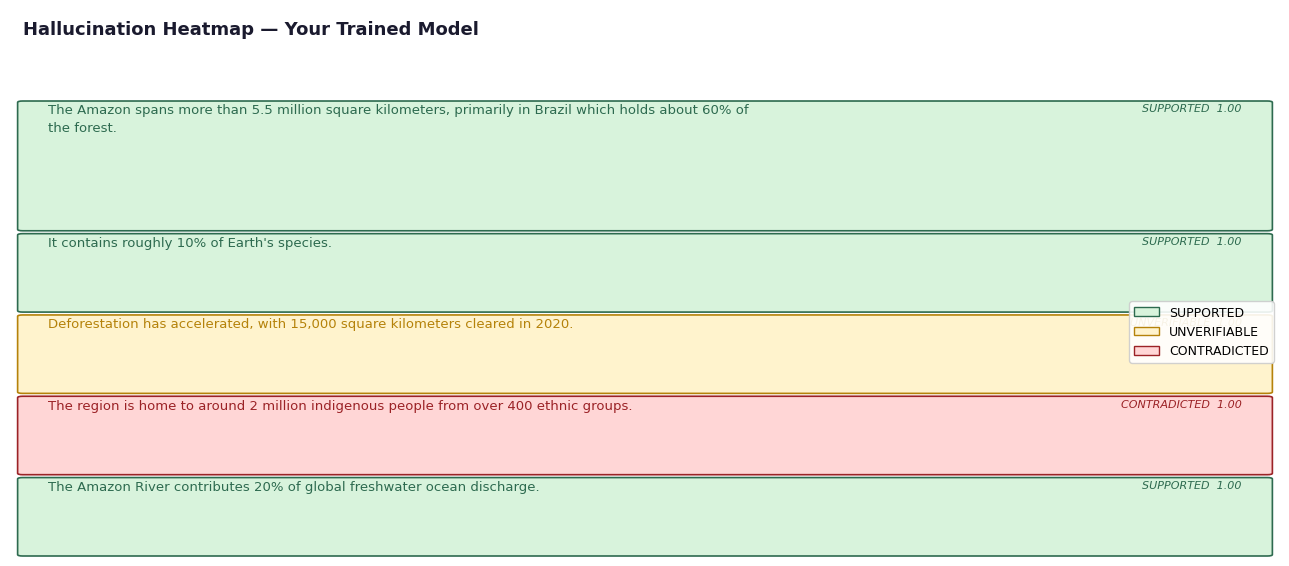

Saved: hallucination_heatmap.png
Saved: hallucination_results.csv


In [24]:
# ── Trust score ───────────────────────────────────────────────────────────────
total       = len(results_df)
supported   = (results_df["label"] == "SUPPORTED").sum()
unverif     = (results_df["label"] == "UNVERIFIABLE").sum()
contradict  = (results_df["label"] == "CONTRADICTED").sum()
trust_score = ((supported * 1.0 + unverif * 0.5) / total) * 100

print("=" * 52)
print("          HALLUCINATION DETECTION REPORT")
print("=" * 52)
print(f"  Total claims     : {total}")
print(f"  Supported        : {supported}  ({supported/total*100:.0f}%)")
print(f"  Unverifiable     : {unverif}  ({unverif/total*100:.0f}%)")
print(f"  Contradicted     : {contradict}  ({contradict/total*100:.0f}%)")
print("-" * 52)
print(f"  TRUST SCORE      : {trust_score:.1f} / 100")
verdict = ("HIGH TRUST" if trust_score >= 85
           else "MODERATE — review flagged sentences" if trust_score >= 60
           else "LOW TRUST — significant hallucination")
print(f"  Verdict          : {verdict}")
print("=" * 52)

# ── Heatmap ───────────────────────────────────────────────────────────────────
color_map = {"SUPPORTED":"#2d6a4f","UNVERIFIABLE":"#b5820a","CONTRADICTED":"#9b2226"}
bg_map    = {"SUPPORTED":"#d8f3dc","UNVERIFIABLE":"#fff3cd","CONTRADICTED":"#ffd6d6"}

fig, ax = plt.subplots(figsize=(13, 0.9 * len(results_df) + 2))
ax.axis("off")
ax.set_xlim(0,1); ax.set_ylim(0,1)

n   = len(results_df)
gap = 1.0 / (n + 2)
y   = 0.97

ax.text(0.01, y, "Hallucination Heatmap — Your Trained Model",
        fontsize=13, fontweight="bold", color="#1a1a2e", transform=ax.transAxes, va="top")
y -= gap * 1.6

for _, row in results_df.iterrows():
    lbl     = row["label"]
    wrapped = textwrap.fill(row["claim"], width=105)
    lines   = wrapped.count("\n") + 1
    bh      = gap * (lines + 0.5)

    rect = mpatches.FancyBboxPatch(
        (0.01, y - bh + 0.004), 0.98, bh - 0.004,
        boxstyle="round,pad=0.004",
        facecolor=bg_map[lbl], edgecolor=color_map[lbl], linewidth=1.2,
        transform=ax.transAxes, clip_on=False,
    )
    ax.add_patch(rect)
    ax.text(0.03, y - 0.004, wrapped,
            fontsize=9.5, color=color_map[lbl], transform=ax.transAxes,
            va="top", linespacing=1.5)
    ax.text(0.97, y - 0.004, f"{lbl}  {row['confidence']:.2f}",
            fontsize=8, color=color_map[lbl], transform=ax.transAxes,
            va="top", ha="right", style="italic")
    y -= bh + 0.012

legend_handles = [
    mpatches.Patch(facecolor=bg_map[l], edgecolor=color_map[l], label=l)
    for l in color_map
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig("hallucination_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hallucination_heatmap.png")

# ── Export CSV ────────────────────────────────────────────────────────────────
results_df.to_csv("hallucination_results.csv", index=False)
print("Saved: hallucination_results.csv")


## 11. Try Your Own Text

In [20]:
my_source = """
PASTE YOUR SOURCE DOCUMENT HERE.
"""

my_summary = """
PASTE THE AI OUTPUT TO VERIFY HERE.
"""

my_results = run_detector(my_source, my_summary)
display(
    my_results[["sentence_id","claim","label","confidence"]]
    .style.applymap(style_label, subset=["label"])
    .hide(axis="index")
)


Source: 1 sentences | Summary: 1 sentences
Running inference with your trained model...



Analyzing:   0%|          | 0/1 [00:00<?, ?it/s]

sentence_id,claim,label,confidence
1,THE AI OUTPUT TO VERIFY HERE.,UNVERIFIABLE,1.000000


## 12. Flask Server — Connect Your Model to the Webpage

Run this cell **last**. It starts a local server on `http://localhost:5000`.  
Keep this cell running, then open `hallucination_detector.html` in your browser.

The webpage will send POST requests to `/detect` and your trained model will respond.

> **Note:** This cell blocks — it runs the server. To stop it press the Stop button in Jupyter.


In [21]:
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)  # allow the local HTML file to call this server

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "running", "model": MODEL_SAVE_PATH})

@app.route("/detect", methods=["POST"])
def detect():
    data    = request.get_json()
    source  = data.get("source", "").strip()
    summary = data.get("summary", "").strip()

    if not source or not summary:
        return jsonify({"error": "Both source and summary are required."}), 400

    try:
        df = run_detector(source, summary)

        total      = len(df)
        supported  = int((df["label"] == "SUPPORTED").sum())
        unverif    = int((df["label"] == "UNVERIFIABLE").sum())
        contradict = int((df["label"] == "CONTRADICTED").sum())
        trust      = round(((supported * 1.0 + unverif * 0.5) / total) * 100, 1)

        if trust >= 85:
            verdict = "The manuscript rings true — well-grounded in evidence."
        elif trust >= 60:
            verdict = "Partial shadows of doubt linger — review the flagged passages."
        else:
            verdict = "The text is riddled with fabrication — trust it not."

        sentences = []
        for _, row in df.iterrows():
            sentences.append({
                "id":         int(row["sentence_id"]),
                "text":       row["claim"],
                "label":      row["label"],
                "confidence": float(row["confidence"]),
                "evidence":   row["top_evidence"],
            })

        return jsonify({
            "sentences":   sentences,
            "trust_score": trust,
            "verdict":     verdict,
            "stats": {
                "supported":    supported,
                "unverifiable": unverif,
                "contradicted": contradict,
                "total":        total,
            }
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500


print("=" * 50)
print("  HALLUCINATION DETECTOR SERVER")
print("=" * 50)
print("  Endpoint : http://localhost:5000/detect")
print("  Health   : http://localhost:5000/health")
print("  Method   : POST  JSON: {source, summary}")
print()
print("  Open hallucination_detector.html in your")
print("  browser — it will use your trained model.")
print()
print("  Press STOP in Jupyter to shut down.")
print("=" * 50)

app.run(host="0.0.0.0", port=5000, debug=False, use_reloader=False)


ModuleNotFoundError: No module named 'flask_cors'